<a href="https://colab.research.google.com/github/rvmvzvn1/Medical-insurance-cost-prediction/blob/main/Medical_Insurance_Cost_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/medical.csv')

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [16]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

In [20]:
X = df.drop('charges',axis=1)
y = df['charges']

In [24]:
categorical_features = ['sex','smoker','region']
numerical_features = ['age','bmi','children']

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

In [27]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

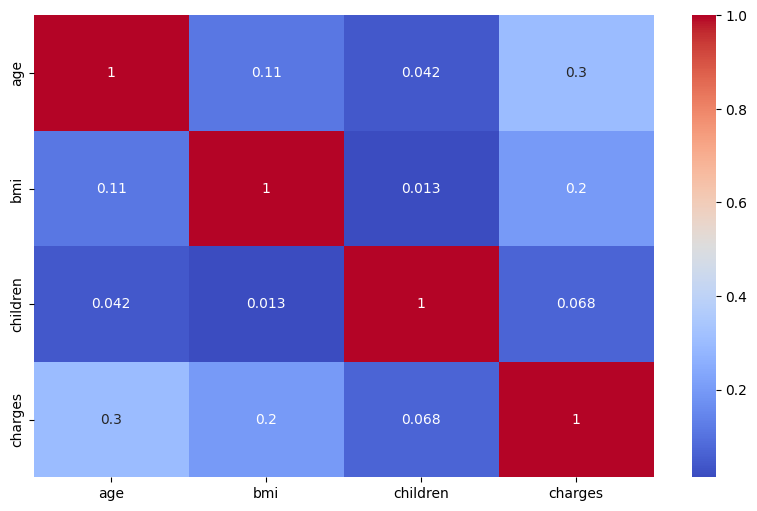

In [29]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

In [30]:
model = LinearRegression()
model.fit(X_train_transformed,y_train)

LinearRegression()

In [32]:
test_predictions = model.predict(X_test_transformed)

In [33]:
MAE = mean_absolute_error(y_test,test_predictions)
MSE = mean_squared_error(y_test,test_predictions)
RMSE = root_mean_squared_error(y_test,test_predictions)

In [34]:
MAE

4051.858766747047

In [35]:
MSE

35479352.80730363

In [36]:
RMSE

5956.454717976427

In [37]:
df['charges'].mean()

np.float64(13270.422265141257)

In [41]:
mscore_train = model.score(X_train_transformed,y_train)
mscore_train

0.7477680686451552

In [43]:
mscore_test = model.score(X_test_transformed,y_test)
mscore_test

0.7623311844057112

In [44]:
overall_linear = pd.Series({'MAE':MAE,'MSE':MSE,'RMSE':RMSE,'mscore_test':mscore_test,'mscore_train':mscore_train})

In [45]:
overall_linear

,0
MAE,4.051859e+03
MSE,3.547935e+07
RMSE,5.956455e+03
mscore_test,7.623312e-01
mscore_train,7.477681e-01


In [46]:
base_elastic_model = ElasticNet()

In [47]:
param_grid = {'alpha':[0.1,1,5,10,50,100],
              'l1_ratio':[.1,.5,.7,.95,.99,1]}

In [48]:
grid_model = GridSearchCV(estimator = base_elastic_model,
                          param_grid = param_grid,
                          scoring = 'neg_mean_squared_error',
                          cv = 5,
                          verbose = 1)

In [49]:
grid_model.fit(X_train_transformed,y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [0.1, 1, 5, 10, 50, 100],
                         'l1_ratio': [0.1, 0.5, 0.7, 0.95, 0.99, 1]},
             scoring='neg_mean_squared_error', verbose=1)

In [50]:
grid_model.best_params_

{'alpha': 0.1, 'l1_ratio': 1}

In [51]:
y_pred = grid_model.predict(X_test_transformed)

In [52]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = root_mean_squared_error(y_test,y_pred)

In [53]:
m_s_train = grid_model.score(X_train_transformed,y_train)
m_s_test = grid_model.score(X_test_transformed,y_test)

In [54]:
overall_elastic = pd.Series({'MAE':mae,'MSE':mse,'RMSE':rmse,'m_s_test':m_s_test,'m_s_train':m_s_train})

In [55]:
overall_elastic

,0
MAE,4.051833e+03
MSE,3.547952e+07
RMSE,5.956469e+03
m_s_test,-3.547952e+07
m_s_train,-3.678776e+07


In [56]:
overall_linear

,0
MAE,4.051859e+03
MSE,3.547935e+07
RMSE,5.956455e+03
mscore_test,7.623312e-01
mscore_train,7.477681e-01
